# Stock Analysis & Backtesting Project

This notebook explores:
- Price behavior of a stock
- Fundamental strength
- Risk characteristics
- Strategy performance vs buy-and-hold

The goal is not prediction, but **evaluation and discipline**.


In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path("..").resolve()
sys.path.append(str(project_root))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import fetch_price_data, fetch_fundamentals
from src.fundamentals import (
    compute_valuation_metrics,
    compute_profitability_metrics,
    compute_growth_metrics,
)
from src.risk import risk_summary
from src.backtest import backtest_strategy


In [3]:
ticker = "AAPL"  # Try RELIANCE.NS for Indian stocks

price_df = fetch_price_data(ticker)
fundamentals = fetch_fundamentals(ticker)

price_df.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2018-01-02 00:00:00-05:00,39.850084,40.351254,39.639309,40.341885,102223600,0.0,0.0
1,2018-01-03 00:00:00-05:00,40.405116,40.878185,40.271629,40.334858,118071600,0.0,0.0
2,2018-01-04 00:00:00-05:00,40.407458,40.625258,40.299731,40.522213,89738400,0.0,0.0
3,2018-01-05 00:00:00-05:00,40.618247,41.070235,40.526912,40.983585,94640000,0.0,0.0
4,2018-01-08 00:00:00-05:00,40.831341,41.126421,40.732977,40.831341,82271200,0.0,0.0


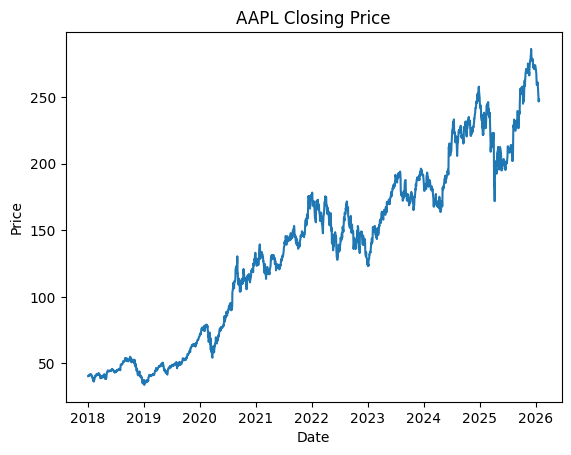

In [4]:
plt.figure()
plt.plot(price_df["Date"], price_df["Close"])
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


In [5]:
valuation = compute_valuation_metrics(fundamentals)
profitability = compute_profitability_metrics(fundamentals)
growth = compute_growth_metrics(fundamentals)

valuation, profitability, growth


({'ticker': 'AAPL',
  'pe_ratio': 33.20482,
  'pb_ratio': 49.697453,
  'valuation_flag': 'overvalued'},
 {'ticker': 'AAPL', 'roe': 1.7142199, 'roe_quality': 'excellent'},
 {'ticker': 'AAPL', 'revenue_growth': 0.079, 'growth_flag': 'moderate_growth'})

### Fundamental Interpretation

- Valuation metrics help assess relative pricing
- ROE reflects efficiency of capital usage
- Growth flags contextualize valuation signals


In [6]:
risk = risk_summary(price_df)
risk


{'volatility': np.float64(0.30722536851513),
 'max_drawdown': np.float64(-0.38515901869237024),
 'avg_daily_return': np.float64(0.0010841969479010614)}

### Risk Perspective

Volatility measures fluctuation, but maximum drawdown captures
the true psychological cost of holding an asset.


In [7]:
results = backtest_strategy(price_df)
results


{'market_return': np.float64(5.148448335157215),
 'strategy_return': np.float64(0.7828757075269244),
 'outperformance': np.float64(-4.365572627630291)}

### Strategy Result

A simple moving-average strategy is compared against buy-and-hold.
Underperformance is acceptable and often expected.
The objective is evaluation, not curve-fitting.


## Conclusion

This project builds a complete research pipeline:
- Data ingestion
- Fundamental analysis
- Risk measurement
- Strategy evaluation

Emphasis is placed on **discipline, consistency,
and quality of execution**.
